# Demo 7: validating the area elements in PyPO

In this notebook, we will investigate and validate the way that `PyPO` calculates area elements. For a more mathematical description of how the elements are calculated, have a look at the "Gridding And Parameterisations" page of the documentation. Here, we will simply check some aspects.

For the first experiment, we generate quadrics at several $uv$-eccentricities and rotation angles, to see if the total area is invariant for different rotation angles. This should hold, as long as we center the $uv$ ellipse on the origin, and as long is the quadrics represent strict surfaces of revolution. We start with paraboloids.

In [16]:
#%matplotlib widget
# Uncomment for interactive plots when running the notebook!
# Requires installation of the ipympl package

import matplotlib.pyplot as plt

import numpy as np
from pathlib import Path
from functools import partial

from scipy.integrate import dblquad

from PyPO.System import System
from PyPO.Enums import Units

def Fv(v, ecc):
    return np.sqrt(np.cos(v)**2 + (1-ecc**2)*np.sin(v)**2)

def uv_to_xy(u, v, rot, x_off, y_off):
    x = u*np.cos(v)*np.cos(rot) - u*np.sin(v)*np.sin(rot) + x_off;
    y = u*np.cos(v)*np.sin(rot) + u*np.sin(v)*np.cos(rot) + y_off;

    return x, y, x-x_off, y-y_off

def area_paraboloid(u, v, a, b, ecc, rot, x_off, y_off):
    x, y, xc, yc = uv_to_xy(u, v, rot, x_off, y_off)
    return np.sqrt(1 + 4*x**2/a**4 + 4*y**2/b**4) * np.sqrt(xc**2 + yc**2)# / Fv(v, ecc)

#def area_paraboloid(u, v, ecc, a, b):
#    return np.sqrt(1 + 4*u**2*(np.cos(v)**2/a**4 + np.sin(v)**2/b**4)) * u# / Fv(v, ecc)

## Planar surfaces
The first class of surfaces we will test are the planes.
We will make 5 disks with ranging number of gridpoints, of fixed size $R=10$ mm. We sum the areas and compare with the true area of a disk of size $R$ which is $\pi R^2$. Then, for a fixed number of gridpoints, we vary the eccentricity $e$ at fixed $R$. This gives us some insights in how well the area elements are calculated by `PyPO`.

2026-03-31 00:20:12 - WARNING - System override set to True. 
2026-03-31 00:20:12 - INFO - Added plane disk to system. 
2026-03-31 00:20:12 - INFO - Added plane disk to system. 
2026-03-31 00:20:12 - INFO - Added plane disk to system. 
2026-03-31 00:20:12 - INFO - Added plane disk to system. 
2026-03-31 00:20:13 - INFO - Added plane disk to system. 


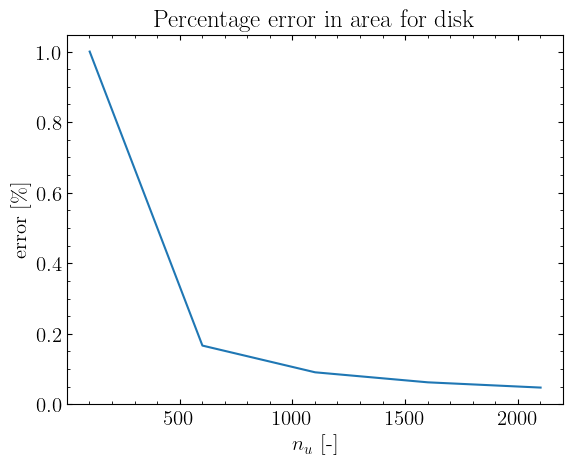

In [2]:
NTEST = 5

R = 10
ecc_uv = 0.9

s = System()

areas_disk = np.zeros(NTEST)
gridsize_u = np.zeros(NTEST)
area_expected = np.pi*R**2

for ii in range(NTEST):
    disk = {
            "name"      : "disk",
            "gmode"     : "uv",
            "pmode"     : "manual",
            "lims_u"    : np.array([0, R])*Units.MM,
            "lims_v"    : np.array([0, 360])*Units.DEG,
            "gridsize"  : np.array([101 + ii*500, 100 + ii*500])
            }
    s.addPlane(disk)
    grids = s.generateGrids("disk")

    areas_disk[ii] = np.nansum(grids.area)
    gridsize_u[ii] = 101 + ii*500

plt.plot(gridsize_u, np.absolute(area_expected - areas_disk) / area_expected * 100)
plt.xlabel(r"$n_u$ [-]")
plt.ylabel("error [\%]")
plt.title("Percentage error in area for disk")
plt.show()

We can see that the error converges to below 0.1% when increasing the gridsize of the $u$ coordinate. Note that the $v$ coordinate increases in the same fashion. Now, let's pick a gridsize of $n_u=1001$ and $v=1000$, fix $R$ again, and vary $e$ between 0 and 0.9 and see how well area is conserved. For fun, we will also rotate the ellipse for each eccentricity, just to see if this affects the area at all (it should not!).

2026-03-31 00:20:14 - INFO - Added plane ellipse to system. 
2026-03-31 00:20:14 - INFO - Added plane ellipse to system. 
2026-03-31 00:20:15 - INFO - Added plane ellipse to system. 
2026-03-31 00:20:15 - INFO - Added plane ellipse to system. 
2026-03-31 00:20:15 - INFO - Added plane ellipse to system. 


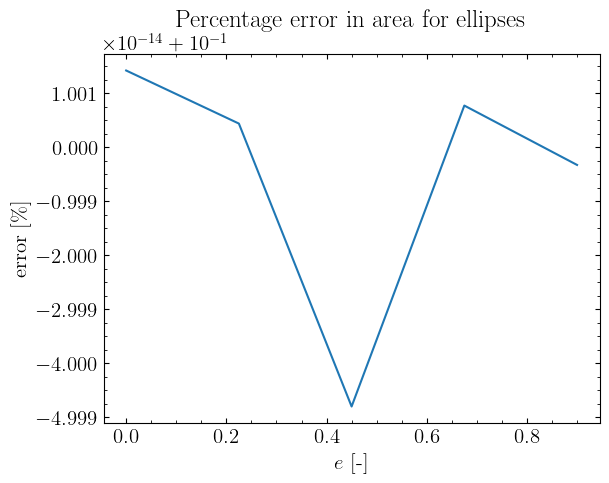

In [3]:
areas_ellipse = np.zeros(NTEST)
areas_expected = np.zeros(NTEST)
ecc_uv = np.zeros(NTEST)

d_ecc = 0.9 / (NTEST - 1)
d_rot = 90 / (NTEST - 1)

for ii in range(NTEST):
    ecc_loc = d_ecc * ii
    areas_expected[ii] = np.pi * R**2 / np.sqrt(1 - ecc_loc**2) 
    disk = {
            "name"      : "ellipse",
            "gmode"     : "uv",
            "pmode"     : "manual",
            "ecc_uv"    : ecc_loc,
            "rot_uv"    : ii * d_rot,
            "lims_u"    : np.array([0, R])*Units.MM,
            "lims_v"    : np.array([0, 360])*Units.DEG,
            "gridsize"  : np.array([1001, 1000])
            }
    s.addPlane(disk)
    grids = s.generateGrids("ellipse")

    areas_ellipse[ii] = np.nansum(grids.area)
    ecc_uv[ii] = ecc_loc
plt.plot(ecc_uv, np.absolute(areas_ellipse - areas_expected) / areas_expected * 100)
plt.xlabel(r"$e$ [-]")
plt.ylabel("error [\%]")
plt.title("Percentage error in area for ellipses")
plt.show()

As can be seen, $e$ has a negligible effect on the percentage error, staying almost constant at an error of 0.1%. As an exercise to the reader, $R$ can be varied and in this way, one can check that the error behaviour stays the same for different $R$.

## Paraboloids
Next, we verify the area conservation by generating a paraboloidal surface of revolution, e.g. a paraboloid with $a=b$ and a $uv$ selection with $e=0$. Since we have verified that area is conserved in the $uv$-plane, and since the total area element is given by $\mathrm{d}A = F(u,v)\mathrm{d}u(v)\mathrm{d}v$, we are now essentially testing the $F(u,v)$ part obtained from the first fundamental form as we have already verified that $\mathrm{d}u(v)\mathrm{d}v$ is working correctly.

Again, we fix $R$.

(8.369746270077158, 7.83001484601649e-11)
2026-03-31 00:27:35 - INFO - Added paraboloid parabola to system. 
0.10388085278211986


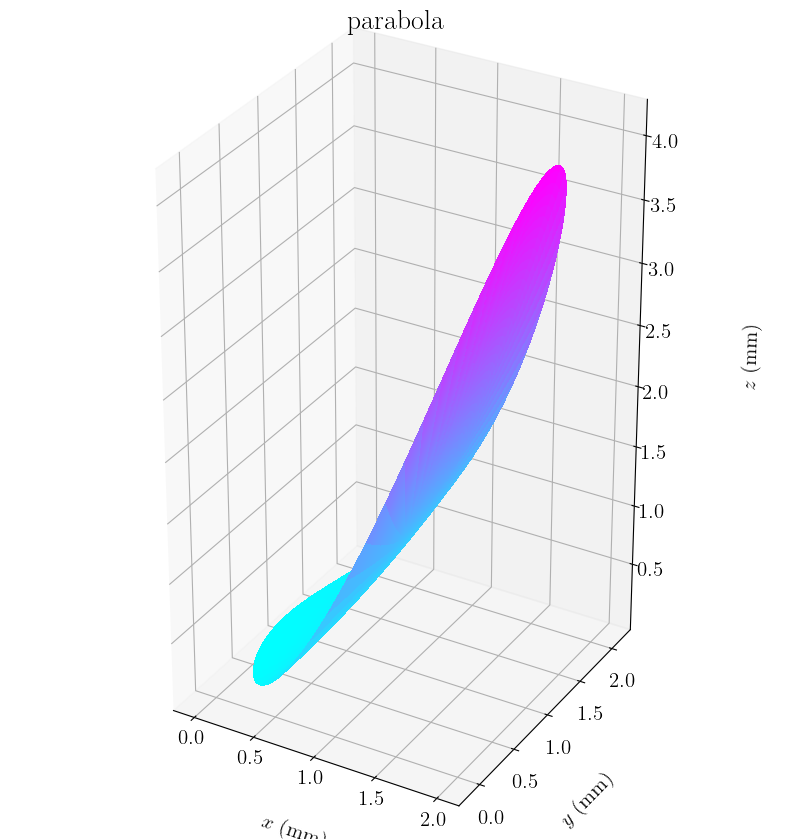

In [21]:

#du_par = u_max/N
#dv_par = v_max/N
#A = np.pi / (6*a_par**2)*((1+4*a_par**2*u_max**2)**(3/2) - 1)
#print(A)

a_par = 1*Units.MM
b_par = 4*Units.MM

u_min = 0*Units.MM
u_max = 1*Units.MM
v_min = 0*Units.DEG
v_max = 360*Units.DEG

x_off = 1
y_off = 1

ecc_uv = 0.5
rot_uv = 156*Units.DEG

Fv_lims = partial(Fv, ecc=ecc_uv)
to_integrate = partial(area_paraboloid, 
                       ecc=ecc_uv, 
                       rot=rot_uv/180*np.pi, 
                       a=a_par, 
                       b=b_par,
                      x_off=x_off,
                      y_off=y_off)

area_int = dblquad(to_integrate, 
                   a=v_min/180*np.pi, 
                   b=v_max/180*np.pi, 
                   gfun=lambda v : u_min/Fv_lims(v), 
                   hfun=lambda v : u_max/Fv_lims(v))
print(area_int)

N = 1001


coeffs = np.array([a_par,b_par])
    
parabola = {
            "name"      : "parabola",
            "gmode"     : "uv",
            "pmode"     : "manual",
            "coeffs"    : coeffs,
            "ecc_uv"    : ecc_uv,
            "rot_uv"    : rot_uv,
            "lims_u"    : np.array([u_min, u_max]),
            "lims_v"    : np.array([v_min, v_max]),
            "gcenter"   : np.array([x_off, y_off])*Units.MM,
            "gridsize"  : np.array([1001, 1000])
            }

s.addParabola(parabola)
grids = s.generateGrids("parabola")

area_tot = np.sum(grids.area)
print(np.absolute(area_tot - area_int[0])/area_int[0]*100)
s.plot3D("parabola")

## Hyperboloids